# Human-Only Analysis by Question Type

Focused analysis of human answer patterns (entropy, accuracy, agreement, confidence)
broken down by **operation type** and entity group. Key finding: operation type
significantly differentiates human behavior while entity group does not.

In [27]:
import sys, numpy as np, pandas as pd
from pathlib import Path
from scipy import stats
from scipy.stats import entropy as sp_entropy
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

ROOT = Path('.').resolve().parent.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'analysis'))
from config import MODELS_7B
from utils.constants import VARIANT_ORDER

EXPORTS = ROOT / 'analysis/session2/exports'
OUT_DIR = Path('.').resolve()
_7b = set(MODELS_7B)

human = pd.read_csv(EXPORTS / 'responses_human.csv')
pc = pd.read_parquet(EXPORTS / 'pair_cache_cleaned.parquet')

# Question metadata from variant C
meta = human[human['variant'] == 'C'].drop_duplicates('question_id')[
    ['question_id', 'question_en', 'ent', 'op', 'gt']
].set_index('question_id')

ENT_MERGE = {
    'person': 'person', 'animal': 'animal', 'object': 'object', 'food': 'food',
    'other': 'other', 'product': 'other', 'place': 'other',
    'vehicle': 'other', 'text': 'other',
}
meta['ent_group'] = meta['ent'].map(ENT_MERGE).fillna('other')

OP_ORDER = ['ident', 'count', 'attr', 'act', 'spat']
OP_LABELS = {'ident': 'Identity', 'count': 'Count', 'attr': 'Attribute',
             'act': 'Action', 'spat': 'Spatial'}
ENT_ORDER = ['person', 'animal', 'object', 'food', 'other']

print(f'Human responses: {len(human):,}')
print(f'Questions: {len(meta)}')
print(f'Participants: {human["participant"].nunique()}')
print(f'Op distribution: {meta["op"].value_counts().to_dict()}')
print(f'Entity distribution: {meta["ent_group"].value_counts().to_dict()}')

Human responses: 13,560
Questions: 113
Participants: 40
Op distribution: {'attr': 41, 'count': 22, 'spat': 12, 'ident': 9, 'exist': 7, 'act': 7, 'text': 5, 'know': 4, 'temp': 3, 'comp': 2, 'cause': 1}
Entity distribution: {'other': 27, 'object': 27, 'person': 26, 'animal': 17, 'food': 16}


## 0. Question Pool Statistics

Breakdown of the 113-question study subset by operation type and entity group,
including yes/no question counts.

In [ ]:
# Identify yes/no questions (>80% of human answers in variant C are yes/no)
hC = human[human['variant'] == 'C']
_yn_frac = hC.groupby('question_id').apply(
    lambda g: g['response'].str.lower().isin(['yes', 'no']).mean(), include_groups=False
)
yesno_set = set(_yn_frac[_yn_frac > 0.8].index)
meta['is_yesno'] = meta.index.isin(yesno_set)

# --- By Operation Type ---
print('=== Questions by Operation Type ===')
op_stats = []
for op in sorted(meta['op'].unique()):
    sub = meta[meta['op'] == op]
    op_stats.append({
        'Operation': op,
        'Total': len(sub),
        'Yes/No': sub['is_yesno'].sum(),
        'Free-text': len(sub) - sub['is_yesno'].sum(),
    })
op_stats.append({
    'Operation': 'ALL',
    'Total': len(meta),
    'Yes/No': meta['is_yesno'].sum(),
    'Free-text': len(meta) - meta['is_yesno'].sum(),
})
op_df = pd.DataFrame(op_stats).set_index('Operation')
op_df['% Yes/No'] = (op_df['Yes/No'] / op_df['Total'] * 100).round(1)
display(op_df)

# --- By Entity Group ---
print('\n=== Questions by Entity Group ===')
ent_stats = []
for eg in ENT_ORDER:
    sub = meta[meta['ent_group'] == eg]
    ent_stats.append({
        'Entity': eg.capitalize(),
        'Total': len(sub),
        'Yes/No': sub['is_yesno'].sum(),
        'Free-text': len(sub) - sub['is_yesno'].sum(),
    })
ent_stats.append({
    'Entity': 'ALL',
    'Total': len(meta),
    'Yes/No': meta['is_yesno'].sum(),
    'Free-text': len(meta) - meta['is_yesno'].sum(),
})
ent_df = pd.DataFrame(ent_stats).set_index('Entity')
ent_df['% Yes/No'] = (ent_df['Yes/No'] / ent_df['Total'] * 100).round(1)
display(ent_df)

# --- Cross-tabulation: Op × Entity ---
print('\n=== Cross-tabulation: Operation × Entity Group (question counts) ===')
cross = pd.crosstab(meta['op'], meta['ent_group'], margins=True, margins_name='Total')
cross = cross.reindex(index=sorted(meta['op'].unique()) + ['Total'],
                      columns=ENT_ORDER + ['Total'])
display(cross)

# Yes/No cross-tab
print('\n=== Yes/No questions: Operation × Entity Group ===')
yn_meta = meta[meta['is_yesno']]
if len(yn_meta) > 0:
    cross_yn = pd.crosstab(yn_meta['op'], yn_meta['ent_group'], margins=True, margins_name='Total')
    display(cross_yn)
else:
    print('No yes/no questions found.')

## 1. Per-Question Human Metrics

For each question and **each variant** (C/B/A): entropy, accuracy, HH SBERT agreement.

In [28]:
# Compute per-question metrics for ALL variants
def answer_entropy(grp):
    counts = grp['response'].value_counts()
    probs = counts / counts.sum()
    return sp_entropy(probs, base=2)

qdf_all = {}  # variant -> qdf
for v in VARIANT_ORDER:
    hv = human[human['variant'] == v]

    h_entropy = hv.groupby('question_id').apply(
        answer_entropy, include_groups=False
    ).rename('entropy')

    h_acc = hv.groupby('question_id')['accuracy'].mean().rename('accuracy')

    hh_sbert = pc[(pc['variant'] == v) & (pc['pair_type'] == 'HH')].groupby(
        'question_id'
    )['sbert_score'].mean().rename('hh_sbert')

    h_nunique = hv.groupby('question_id')['response'].nunique().rename('n_unique')

    df = pd.DataFrame({
        'entropy': h_entropy, 'accuracy': h_acc,
        'hh_sbert': hh_sbert, 'n_unique': h_nunique,
    }).join(meta)
    df['variant'] = v
    qdf_all[v] = df

# Primary reference: variant C
hC = human[human['variant'] == 'C']
qdf = qdf_all['C']

print(f'Questions with all metrics (per variant):')
for v in VARIANT_ORDER:
    print(f'  {v}: {len(qdf_all[v].dropna())}')
print(f'\nGlobal stats (variant C):')
print(qdf[['entropy', 'accuracy', 'hh_sbert', 'n_unique']].describe().round(3))

Questions with all metrics (per variant):
  C: 88
  B: 88
  A: 88

Global stats (variant C):
       entropy  accuracy  hh_sbert  n_unique
count  113.000   113.000    88.000   113.000
mean     2.932     0.262     0.514    14.912
std      1.380     0.285     0.162    10.151
min      0.610     0.000     0.183     2.000
25%      1.940     0.025     0.385     7.000
50%      3.114     0.150     0.530    14.000
75%      3.983     0.475     0.653    22.000
max      5.272     1.000     0.783    39.000


## 2. Human Patterns by Operation Type

In [29]:
# Table: human metrics by op × variant
op_rows = []
for op in OP_ORDER:
    row = {'Operation': OP_LABELS[op], 'N': len(qdf[qdf['op'] == op])}
    for v in VARIANT_ORDER:
        sub = qdf_all[v][qdf_all[v]['op'] == op]
        row[f'Entropy {v}'] = sub['entropy'].mean()
        row[f'Acc {v}'] = sub['accuracy'].mean()
        row[f'HH SBERT {v}'] = sub['hh_sbert'].mean()
    op_rows.append(row)

# All row
row_all = {'Operation': 'All', 'N': len(qdf)}
for v in VARIANT_ORDER:
    row_all[f'Entropy {v}'] = qdf_all[v]['entropy'].mean()
    row_all[f'Acc {v}'] = qdf_all[v]['accuracy'].mean()
    row_all[f'HH SBERT {v}'] = qdf_all[v]['hh_sbert'].mean()
op_rows.append(row_all)

op_tbl = pd.DataFrame(op_rows).set_index('Operation')
fmt = {'N': '{:d}'}
for v in VARIANT_ORDER:
    fmt[f'Entropy {v}'] = '{:.2f}'
    fmt[f'Acc {v}'] = '{:.3f}'
    fmt[f'HH SBERT {v}'] = '{:.3f}'
display(op_tbl.style.format(fmt))

# ANOVA on variant C
groups = [qdf[qdf['op'] == op]['entropy'].values for op in OP_ORDER if len(qdf[qdf['op'] == op]) > 1]
F, p = stats.f_oneway(*groups)
print(f'\nANOVA entropy ~ op (variant C): F={F:.2f}, p={p:.4f}')

# Check ANOVA holds across variants
for v in VARIANT_ORDER:
    vdf = qdf_all[v]
    groups_v = [vdf[vdf['op'] == op]['entropy'].values for op in OP_ORDER if len(vdf[vdf['op'] == op]) > 1]
    Fv, pv = stats.f_oneway(*groups_v)
    print(f'  Variant {v}: F={Fv:.2f}, p={pv:.4f}')

,N,Entropy C,Acc C,HH SBERT C,Entropy B,Acc B,HH SBERT B,Entropy A,Acc A,HH SBERT A
Operation,,,,,,,,,,
Identity,9,3.64,0.077,0.534,4.06,0.050,0.456,4.55,0.017,0.337
Count,22,2.98,0.226,0.662,2.94,0.229,0.661,3.00,0.201,0.671
Attribute,41,2.78,0.284,0.472,3.02,0.235,0.430,3.05,0.229,0.423
Action,7,1.79,0.455,0.518,1.81,0.431,0.499,1.90,0.423,0.494
Spatial,12,3.80,0.162,0.401,3.65,0.122,0.411,4.03,0.105,0.360
All,113,2.93,0.262,0.514,3.03,0.229,0.491,3.15,0.225,0.472



ANOVA entropy ~ op (variant C): F=4.05, p=0.0047
  Variant C: F=4.05, p=0.0047
  Variant B: F=3.86, p=0.0062
  Variant A: F=5.94, p=0.0003


In [30]:
# Bootstrap CIs and permutation test for robustness with unequal N
rng = np.random.default_rng(42)
N_BOOT = 5000
N_PERM = 10000

# 1. Bootstrap 95% CI for each group mean
print('=== Bootstrap 95% CI for mean entropy by op (5000 resamples) ===')
boot_ci = {}
for op in OP_ORDER:
    vals = qdf[qdf['op'] == op]['entropy'].values
    n = len(vals)
    boot_means = [np.mean(rng.choice(vals, size=n, replace=True)) for _ in range(N_BOOT)]
    lo, hi = np.percentile(boot_means, [2.5, 97.5])
    boot_ci[op] = (lo, hi)
    print('  {:10s}: mean={:.2f}, 95% CI=[{:.2f}, {:.2f}], N={}'.format(
        OP_LABELS[op], np.mean(vals), lo, hi, n))

# 2. Permutation ANOVA
obs_F, _ = stats.f_oneway(*[qdf[qdf['op'] == op]['entropy'].values for op in OP_ORDER])
all_entropy = qdf['entropy'].values
all_op = qdf['op'].values
perm_count = 0
for _ in range(N_PERM):
    perm_op = rng.permutation(all_op)
    groups_perm = [all_entropy[perm_op == op] for op in OP_ORDER if (perm_op == op).sum() > 0]
    if len(groups_perm) >= 2:
        F_perm, _ = stats.f_oneway(*groups_perm)
        if F_perm >= obs_F:
            perm_count += 1
p_perm = perm_count / N_PERM

# Kruskal-Wallis (non-parametric)
H_stat, p_kw = stats.kruskal(*[qdf[qdf['op'] == op]['entropy'].values for op in OP_ORDER])

print('\n=== Non-parametric tests ===')
print('  Permutation ANOVA: F={:.2f}, p={:.4f}'.format(obs_F, p_perm))
print('  Kruskal-Wallis:    H={:.2f}, p={:.4f}'.format(H_stat, p_kw))

# 3. Pairwise bootstrap differences
print('\n=== Pairwise bootstrap: act vs others ===')
act_vals = qdf[qdf['op'] == 'act']['entropy'].values
for op in ['ident', 'count', 'attr', 'spat']:
    other_vals = qdf[qdf['op'] == op]['entropy'].values
    obs_diff = np.mean(act_vals) - np.mean(other_vals)
    boot_diffs = [
        np.mean(rng.choice(act_vals, size=len(act_vals), replace=True)) -
        np.mean(rng.choice(other_vals, size=len(other_vals), replace=True))
        for _ in range(N_BOOT)
    ]
    lo, hi = np.percentile(boot_diffs, [2.5, 97.5])
    sig = 'Yes' if lo > 0 or hi < 0 else 'No'
    print('  act - {:10s}: diff={:+.2f}, 95% CI=[{:+.2f}, {:+.2f}], sig={}'.format(
        OP_LABELS[op], obs_diff, lo, hi, sig))

# 4. Effect size
SS_between = sum(
    len(qdf[qdf['op'] == op]) * (qdf[qdf['op'] == op]['entropy'].mean() - qdf['entropy'].mean())**2
    for op in OP_ORDER
)
SS_total = ((qdf['entropy'] - qdf['entropy'].mean())**2).sum()
eta_sq = SS_between / SS_total
print('\nEffect size: eta^2 = {:.3f}'.format(eta_sq))

=== Bootstrap 95% CI for mean entropy by op (5000 resamples) ===
  Identity  : mean=3.64, 95% CI=[3.20, 4.18], N=9
  Count     : mean=2.98, 95% CI=[2.75, 3.21], N=22
  Attribute : mean=2.78, 95% CI=[2.32, 3.24], N=41
  Action    : mean=1.79, 95% CI=[0.90, 2.93], N=7
  Spatial   : mean=3.80, 95% CI=[3.24, 4.29], N=12



=== Non-parametric tests ===
  Permutation ANOVA: F=4.05, p=0.0039
  Kruskal-Wallis:    H=12.69, p=0.0129

=== Pairwise bootstrap: act vs others ===
  act - Identity  : diff=-1.85, 95% CI=[-2.88, -0.60], sig=Yes
  act - Count     : diff=-1.19, 95% CI=[-2.11, +0.00], sig=No
  act - Attribute : diff=-0.99, 95% CI=[-2.01, +0.25], sig=No
  act - Spatial   : diff=-2.01, 95% CI=[-3.07, -0.73], sig=Yes

Effect size: eta^2 = 0.111


## 3. Human Patterns by Entity Group

In [31]:
# Table: human metrics by entity × variant
ent_rows = []
for eg in ENT_ORDER:
    row = {'Entity': eg.capitalize(), 'N': len(qdf[qdf['ent_group'] == eg])}
    for v in VARIANT_ORDER:
        sub = qdf_all[v][qdf_all[v]['ent_group'] == eg]
        row[f'Entropy {v}'] = sub['entropy'].mean()
        row[f'Acc {v}'] = sub['accuracy'].mean()
        row[f'HH SBERT {v}'] = sub['hh_sbert'].mean()
    ent_rows.append(row)

row_all = {'Entity': 'All', 'N': len(qdf)}
for v in VARIANT_ORDER:
    row_all[f'Entropy {v}'] = qdf_all[v]['entropy'].mean()
    row_all[f'Acc {v}'] = qdf_all[v]['accuracy'].mean()
    row_all[f'HH SBERT {v}'] = qdf_all[v]['hh_sbert'].mean()
ent_rows.append(row_all)

ent_tbl = pd.DataFrame(ent_rows).set_index('Entity')
fmt = {'N': '{:d}'}
for v in VARIANT_ORDER:
    fmt[f'Entropy {v}'] = '{:.2f}'
    fmt[f'Acc {v}'] = '{:.3f}'
    fmt[f'HH SBERT {v}'] = '{:.3f}'
display(ent_tbl.style.format(fmt))

# ANOVA across variants
for v in VARIANT_ORDER:
    vdf = qdf_all[v]
    groups_ent = [vdf[vdf['ent_group'] == eg]['entropy'].values for eg in ENT_ORDER]
    Fv, pv = stats.f_oneway(*groups_ent)
    print(f'ANOVA entropy ~ entity (variant {v}): F={Fv:.2f}, p={pv:.4f}')

,N,Entropy C,Acc C,HH SBERT C,Entropy B,Acc B,HH SBERT B,Entropy A,Acc A,HH SBERT A
Entity,,,,,,,,,,
Person,26,3.01,0.218,0.479,3.22,0.182,0.444,3.11,0.199,0.454
Animal,17,2.73,0.375,0.534,2.74,0.317,0.513,3.03,0.314,0.461
Object,27,2.91,0.224,0.545,3.10,0.195,0.517,3.31,0.147,0.497
Food,16,2.58,0.344,0.566,2.75,0.315,0.528,2.99,0.318,0.470
Other,27,3.22,0.224,0.477,3.13,0.200,0.479,3.20,0.216,0.470
All,113,2.93,0.262,0.514,3.03,0.229,0.491,3.15,0.225,0.472


ANOVA entropy ~ entity (variant C): F=0.65, p=0.6297
ANOVA entropy ~ entity (variant B): F=0.48, p=0.7527
ANOVA entropy ~ entity (variant A): F=0.17, p=0.9547


## 4. Visualisation: Entropy by Operation Type

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
variant_colors = {'C': '#1f77b4', 'B': '#ff7f0e', 'A': '#2ca02c'}

for vi, v in enumerate(VARIANT_ORDER):
    ax = axes[vi]
    vdf = qdf_all[v]
    data_op = [vdf[vdf['op'] == op]['entropy'].values for op in OP_ORDER]
    bp = ax.boxplot(data_op, labels=[OP_LABELS[op] for op in OP_ORDER],
                    patch_artist=True, widths=0.6)
    for patch in bp['boxes']:
        patch.set_facecolor(variant_colors[v])
        patch.set_alpha(0.6)
    ax.set_ylabel('Answer entropy (bits)' if vi == 0 else '')
    ax.set_title(f'Variant {v}')
    ax.set_ylim(-0.2, 6.0)
    for i, op in enumerate(OP_ORDER):
        n = len(vdf[vdf['op'] == op])
        ax.text(i + 1, -0.1, f'n={n}', ha='center', fontsize=8, color='gray')

fig.suptitle('Human answer entropy by operation type × variant', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'human_entropy_by_type.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: human_entropy_by_type.png')

## 5. Entropy–Accuracy Relationship by Op

Do high-entropy (diverse) questions also have low accuracy? This tests whether
human diversity reflects genuine ambiguity vs random guessing.

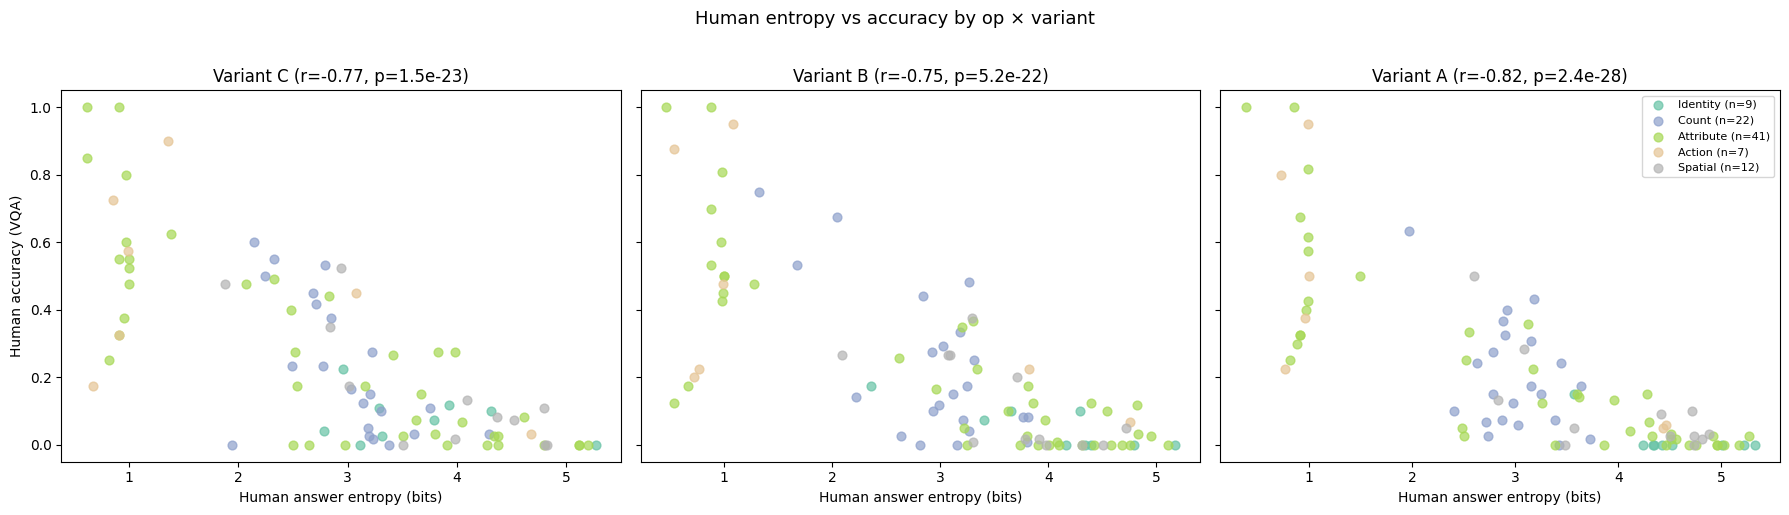

Variant C: r=-0.772, p=1.5e-23
Variant B: r=-0.754, p=5.2e-22
Variant A: r=-0.817, p=2.4e-28


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
op_colors = plt.cm.Set2(np.linspace(0, 1, len(OP_ORDER)))

for vi, v in enumerate(VARIANT_ORDER):
    ax = axes[vi]
    vdf = qdf_all[v]
    for i, op in enumerate(OP_ORDER):
        sub = vdf[vdf['op'] == op]
        ax.scatter(sub['entropy'], sub['accuracy'],
                   label=f'{OP_LABELS[op]} (n={len(sub)})',
                   alpha=0.7, s=40, color=op_colors[i])

    valid = vdf[['entropy', 'accuracy']].dropna()
    r, p = stats.pearsonr(valid['entropy'], valid['accuracy'])
    ax.set_xlabel('Human answer entropy (bits)')
    if vi == 0:
        ax.set_ylabel('Human accuracy (VQA)')
    ax.set_title(f'Variant {v} (r={r:.2f}, p={p:.1e})')
    if vi == 2:
        ax.legend(fontsize=8, loc='upper right')

fig.suptitle('Human entropy vs accuracy by op × variant', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'human_entropy_vs_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

# Print per-variant correlations
for v in VARIANT_ORDER:
    vdf = qdf_all[v]
    valid = vdf[['entropy', 'accuracy']].dropna()
    r, p = stats.pearsonr(valid['entropy'], valid['accuracy'])
    print(f'Variant {v}: r={r:.3f}, p={p:.1e}')

## 6. Variant Stability: Human Entropy Across Variants

Do humans maintain similar diversity patterns across variants A/B/C?
If so, human behavior is robust to entity manipulation.

In [34]:
# Compute per-question entropy for each variant
variant_entropy = {}
for v in VARIANT_ORDER:
    hv = human[human['variant'] == v]
    ve = hv.groupby('question_id').apply(
        answer_entropy, include_groups=False
    )
    variant_entropy[f'entropy_{v}'] = ve

ve_df = pd.DataFrame(variant_entropy).join(meta[['op', 'ent_group']])

# Pairwise correlations
print('Human entropy correlation across variants:')
for v1, v2 in [('C', 'B'), ('C', 'A'), ('B', 'A')]:
    valid = ve_df[[f'entropy_{v1}', f'entropy_{v2}']].dropna()
    r, p = stats.pearsonr(valid.iloc[:, 0], valid.iloc[:, 1])
    print(f'  {v1} vs {v2}: r={r:.3f}, p={p:.1e}, N={len(valid)}')

print()
print('Mean entropy by variant:')
for v in VARIANT_ORDER:
    col = f'entropy_{v}'
    print(f'  {v}: {ve_df[col].mean():.3f} ± {ve_df[col].std():.3f}')

# By op within each variant
print()
print('Mean human entropy by op × variant:')
for op in OP_ORDER:
    vals = []
    for v in VARIANT_ORDER:
        col = f'entropy_{v}'
        sub = ve_df[ve_df['op'] == op]
        vals.append(f'{sub[col].mean():.2f}')
    print(f'  {op:6s}: ' + ' / '.join(f'{v}={val}' for v, val in zip(VARIANT_ORDER, vals)))

Human entropy correlation across variants:
  C vs B: r=0.920, p=4.2e-47, N=113
  C vs A: r=0.891, p=8.2e-40, N=113
  B vs A: r=0.913, p=5.2e-45, N=113

Mean entropy by variant:
  C: 2.932 ± 1.380
  B: 3.031 ± 1.432
  A: 3.151 ± 1.471

Mean human entropy by op × variant:
  ident : C=3.64 / B=4.06 / A=4.55
  count : C=2.98 / B=2.94 / A=3.00
  attr  : C=2.78 / B=3.02 / A=3.05
  act   : C=1.79 / B=1.81 / A=1.90
  spat  : C=3.80 / B=3.65 / A=4.03


## 7. HH Agreement by Op: Do Humans Agree More on Certain Question Types?

In [35]:
# HH SBERT by op and variant
hh_rows = []
for v in VARIANT_ORDER:
    hh_v = pc[(pc['variant'] == v) & (pc['pair_type'] == 'HH')].groupby(
        'question_id'
    )['sbert_score'].mean()
    tmp = hh_v.to_frame('hh').join(meta[['op', 'ent_group']])
    for op in OP_ORDER:
        sub = tmp[tmp['op'] == op]
        hh_rows.append({
            'Variant': v, 'Operation': OP_LABELS[op],
            'N': len(sub), 'HH SBERT': sub['hh'].mean(),
        })

hh_tbl = pd.DataFrame(hh_rows)
hh_pivot = hh_tbl.pivot(index='Operation', columns='Variant', values='HH SBERT')
hh_pivot = hh_pivot.reindex([OP_LABELS[op] for op in OP_ORDER])
hh_pivot['C-A gap'] = hh_pivot['C'] - hh_pivot['A']
display(hh_pivot.style.format('{:.3f}'))

print()
print('Key: C-A gap shows how much human agreement drops when entities are removed.')
print('Near-zero gaps mean humans are robust to entity manipulation.')

Variant,A,B,C,C-A gap
Operation,,,,
Identity,0.337,0.456,0.534,0.198
Count,0.671,0.661,0.662,-0.008
Attribute,0.423,0.430,0.472,0.049
Action,0.494,0.499,0.518,0.025
Spatial,0.360,0.411,0.401,0.041



Key: C-A gap shows how much human agreement drops when entities are removed.
Near-zero gaps mean humans are robust to entity manipulation.


## 8. Confidence by Operation Type

Human self-reported confidence (1-5 scale, normalized to [0,1]).

In [36]:
# Check if confidence column exists
if 'confidence' in human.columns:
    hC_conf = hC[hC['confidence'].notna()]
    conf_q = hC_conf.groupby('question_id')['confidence'].mean().rename('confidence')
    qdf_conf = qdf.join(conf_q)

    print('Human confidence by operation type (variant C):')
    for op in OP_ORDER:
        sub = qdf_conf[qdf_conf['op'] == op]
        c = sub['confidence'].dropna()
        print(f'  {op:6s}: {c.mean():.3f} ± {c.std():.3f}  (N={len(c)})')
    print(f'  {"All":6s}: {qdf_conf["confidence"].mean():.3f} ± {qdf_conf["confidence"].std():.3f}')

    # Correlation: confidence vs entropy
    valid = qdf_conf[['confidence', 'entropy']].dropna()
    r, p = stats.pearsonr(valid['confidence'], valid['entropy'])
    print(f'\nConfidence vs entropy: r={r:.3f}, p={p:.1e}')

    # Correlation: confidence vs accuracy
    valid2 = qdf_conf[['confidence', 'accuracy']].dropna()
    r2, p2 = stats.pearsonr(valid2['confidence'], valid2['accuracy'])
    print(f'Confidence vs accuracy: r={r2:.3f}, p={p2:.1e}')

    F_c, p_c = stats.f_oneway(*[
        qdf_conf[qdf_conf['op'] == op]['confidence'].dropna().values
        for op in OP_ORDER if len(qdf_conf[qdf_conf['op'] == op]['confidence'].dropna()) > 1
    ])
    print(f'\nANOVA confidence ~ op: F={F_c:.2f}, p={p_c:.4f}')
else:
    print('No confidence column in human responses.')
    # Try loading from confidence data
    conf_path = EXPORTS.parent.parent / 'evaluation/humans/confidence'
    print(f'Check: {conf_path.exists()}')

No confidence column in human responses.
Check: False


## 9. Yes/No Questions: A Special Case

Yes/no questions have constrained answer space (max entropy = 1 bit).
Do they behave differently by op?

In [37]:
# Separate yes/no vs free-text (using variant C to identify)
hC = human[human['variant'] == 'C']
def yesno_frac(grp):
    answers = grp['response'].str.lower()
    return answers.isin(['yes', 'no']).mean()

yn_frac = hC.groupby('question_id').apply(yesno_frac, include_groups=False)
yesno_qids = set(yn_frac[yn_frac > 0.8].index)
freetext_qids = set(yn_frac[yn_frac <= 0.8].index)

print(f'Yes/no questions: {len(yesno_qids)}')
print(f'Free-text questions: {len(freetext_qids)}')

# Compare entropy by op × variant, split by yes/no vs free-text
for v in VARIANT_ORDER:
    vdf = qdf_all[v]
    print(f'\n--- Variant {v}: Mean entropy by op (Yes/No vs Free-text) ---')
    print(f'{"Op":8s} {"YN":>16s} {"Free":>16s}')
    for op in OP_ORDER:
        sub_yn = vdf[(vdf['op'] == op) & (vdf.index.isin(yesno_qids))]
        sub_ft = vdf[(vdf['op'] == op) & (vdf.index.isin(freetext_qids))]
        yn_str = f'{sub_yn["entropy"].mean():.2f} (n={len(sub_yn)})' if len(sub_yn) > 0 else '-'
        ft_str = f'{sub_ft["entropy"].mean():.2f} (n={len(sub_ft)})' if len(sub_ft) > 0 else '-'
        print(f'{op:8s} {yn_str:>16s} {ft_str:>16s}')

Yes/no questions: 26
Free-text questions: 87

--- Variant C: Mean entropy by op (Yes/No vs Free-text) ---
Op                     YN             Free
ident                   -       3.64 (n=9)
count                   -      2.98 (n=22)
attr          0.89 (n=12)      3.57 (n=29)
act            0.95 (n=5)       3.88 (n=2)
spat                    -      3.80 (n=12)

--- Variant B: Mean entropy by op (Yes/No vs Free-text) ---
Op                     YN             Free
ident                   -       4.06 (n=9)
count                   -      2.94 (n=22)
attr          0.85 (n=12)      3.91 (n=29)
act            0.82 (n=5)       4.29 (n=2)
spat                    -      3.65 (n=12)

--- Variant A: Mean entropy by op (Yes/No vs Free-text) ---
Op                     YN             Free
ident                   -       4.55 (n=9)
count                   -      3.00 (n=22)
attr          0.88 (n=12)      3.94 (n=29)
act            0.89 (n=5)       4.45 (n=2)
spat                    -      4.03 (n=12

## 9b. Top and Bottom Questions by HH Agreement

Which questions do humans agree on most (high HH SBERT) and least (low HH SBERT)?

In [38]:
# Top/bottom questions by HH SBERT — show all variants
def top_answers_v(qid, variant, n=3):
    hv = human[(human['variant'] == variant) & (human['question_id'] == qid)]
    counts = hv['response'].value_counts().head(n)
    return ', '.join('{} ({})'.format(a, c) for a, c in counts.items())

for v in VARIANT_ORDER:
    vdf = qdf_all[v]
    vdf_hh = vdf[vdf['hh_sbert'].notna()].copy()

    print(f'\n{"="*70}')
    print(f'VARIANT {v}: TOP 10 Highest HH SBERT (humans agree most)')
    print(f'{"="*70}\n')
    top10 = vdf_hh.nlargest(10, 'hh_sbert')
    for qid, row in top10.iterrows():
        q = str(row['question_en'])[:60]
        answers = top_answers_v(qid, v)
        print('{:6s} | {:5s} | HH={:.3f} | H={:.2f} | acc={:.3f}'.format(
            row['op'], str(row.get('ent', '')), row['hh_sbert'], row['entropy'], row['accuracy']))
        print('  Q: "{}"'.format(q))
        print('  Top answers: {}'.format(answers))
        print()

    print(f'\n{"="*70}')
    print(f'VARIANT {v}: BOTTOM 10 Lowest HH SBERT (humans disagree most)')
    print(f'{"="*70}\n')
    bot10 = vdf_hh.nsmallest(10, 'hh_sbert')
    for qid, row in bot10.iterrows():
        q = str(row['question_en'])[:60]
        answers = top_answers_v(qid, v)
        print('{:6s} | {:5s} | HH={:.3f} | H={:.2f} | acc={:.3f}'.format(
            row['op'], str(row.get('ent', '')), row['hh_sbert'], row['entropy'], row['accuracy']))
        print('  Q: "{}"'.format(q))
        print('  Top answers: {}'.format(answers))
        print()

# Op distribution comparison
print('\n--- Op distribution in top/bottom 10 by variant ---')
for v in VARIANT_ORDER:
    vdf_hh = qdf_all[v][qdf_all[v]['hh_sbert'].notna()]
    top10 = vdf_hh.nlargest(10, 'hh_sbert')
    bot10 = vdf_hh.nsmallest(10, 'hh_sbert')
    print(f'Variant {v}: Top={top10["op"].value_counts().to_dict()}, Bot={bot10["op"].value_counts().to_dict()}')


VARIANT C: TOP 10 Highest HH SBERT (humans agree most)

count  | object | HH=0.783 | H=1.94 | acc=0.000
  Q: "How many bottles of water are on the table?"
  Top answers: 1 (16), 3 (11), 2 (10)

act    | animal | HH=0.770 | H=1.36 | acc=0.900
  Q: "Do the horses love each other?"
  Top answers: yes (28), no (8), not really (1)

count  | food  | HH=0.770 | H=2.24 | acc=0.500
  Q: "How many hot dogs are on this bun?"
  Top answers: 1 (21), 3 (6), 2 (6)

attr   | object | HH=0.761 | H=2.07 | acc=0.475
  Q: "What color are the appliances?"
  Top answers: white (18), black (13), gray (3)

count  | product | HH=0.756 | H=2.14 | acc=0.600
  Q: "How many earrings does the man have?"
  Top answers: 2 (18), 1 (9), 0 (7)

count  | object | HH=0.750 | H=2.33 | acc=0.550
  Q: "How many ski poles is this person holding?"
  Top answers: 2 (22), 1 (5), 3 (4)

count  | object | HH=0.740 | H=2.71 | acc=0.417
  Q: "How many train track are there?"
  Top answers: 2 (14), 3 (8), 1 (5)

attr   | object | HH

## 10. Within-Group Degradation: Which Question Types Are Most Affected by Entity Removal?

Paired t-tests on HH SBERT (C vs A) within each operation and entity group.
Questions: Does entity removal hurt agreement uniformly, or do some question types collapse more?

In [39]:
# Within-group degradation: paired t-tests on HH SBERT (C vs A)
# Each question serves as its own control across variants

# Build per-question HH SBERT for C and A
hh_by_v = {}
for v in ['C', 'A']:
    hh_v = pc[(pc['variant'] == v) & (pc['pair_type'] == 'HH')].groupby(
        'question_id'
    )['sbert_score'].mean()
    hh_by_v[v] = hh_v

hh_ca = pd.DataFrame({'hh_C': hh_by_v['C'], 'hh_A': hh_by_v['A']}).join(meta[['op', 'ent_group']]).dropna()
hh_ca['delta'] = hh_ca['hh_C'] - hh_ca['hh_A']  # positive = degradation under entity removal

print(f'Paired questions with HH SBERT in both C and A: {len(hh_ca)}')
print(f'Overall: mean Δ = {hh_ca["delta"].mean():.3f}, '
      f't={stats.ttest_rel(hh_ca["hh_C"], hh_ca["hh_A"]).statistic:.2f}, '
      f'p={stats.ttest_rel(hh_ca["hh_C"], hh_ca["hh_A"]).pvalue:.4f}')

# --- By operation type ---
print('\n=== Within-Op Degradation (C → A) ===')
print(f'{"Op":<12s} {"N":>4s} {"HH_C":>7s} {"HH_A":>7s} {"Δ":>7s} {"t":>7s} {"p":>8s} {"sig":>4s}')
print('-' * 60)
for op in OP_ORDER:
    sub = hh_ca[hh_ca['op'] == op]
    if len(sub) < 2:
        print(f'{OP_LABELS[op]:<12s} {len(sub):>4d}   (too few)')
        continue
    t_stat, p_val = stats.ttest_rel(sub['hh_C'], sub['hh_A'])
    sig = '*' if p_val < 0.05 else ('†' if p_val < 0.1 else '')
    print(f'{OP_LABELS[op]:<12s} {len(sub):>4d} {sub["hh_C"].mean():>7.3f} {sub["hh_A"].mean():>7.3f} '
          f'{sub["delta"].mean():>+7.3f} {t_stat:>7.2f} {p_val:>8.4f} {sig:>4s}')

# --- By entity group ---
print('\n=== Within-Entity Degradation (C → A) ===')
print(f'{"Entity":<12s} {"N":>4s} {"HH_C":>7s} {"HH_A":>7s} {"Δ":>7s} {"t":>7s} {"p":>8s} {"sig":>4s}')
print('-' * 60)
for eg in ENT_ORDER:
    sub = hh_ca[hh_ca['ent_group'] == eg]
    if len(sub) < 2:
        print(f'{eg.capitalize():<12s} {len(sub):>4d}   (too few)')
        continue
    t_stat, p_val = stats.ttest_rel(sub['hh_C'], sub['hh_A'])
    sig = '*' if p_val < 0.05 else ('†' if p_val < 0.1 else '')
    print(f'{eg.capitalize():<12s} {len(sub):>4d} {sub["hh_C"].mean():>7.3f} {sub["hh_A"].mean():>7.3f} '
          f'{sub["delta"].mean():>+7.3f} {t_stat:>7.2f} {p_val:>8.4f} {sig:>4s}')

print('\n* p < 0.05, † p < 0.10')

Paired questions with HH SBERT in both C and A: 88
Overall: mean Δ = 0.042, t=3.44, p=0.0009

=== Within-Op Degradation (C → A) ===
Op              N    HH_C    HH_A       Δ       t        p  sig
------------------------------------------------------------
Identity        9   0.534   0.337  +0.198    4.49   0.0020    *
Count          22   0.662   0.671  -0.008   -0.60   0.5539     
Attribute      29   0.472   0.423  +0.049    2.16   0.0397    *
Action          3   0.518   0.494  +0.025    0.42   0.7169     
Spatial        12   0.401   0.360  +0.041    1.59   0.1395     

=== Within-Entity Degradation (C → A) ===
Entity          N    HH_C    HH_A       Δ       t        p  sig
------------------------------------------------------------
Person         20   0.479   0.454  +0.026    1.09   0.2882     
Animal         12   0.534   0.461  +0.073    2.05   0.0653    †
Object         23   0.545   0.497  +0.048    2.03   0.0550    †
Food           11   0.566   0.470  +0.096    2.85   0.0171    *

In [40]:
# Highest C->A degradation questions in HH SBERT
# Show the strongest human anchor-sensitive cases directly.

def top_answers_v(qid, variant, n=5):
    hv = human[(human['variant'] == variant) & (human['question_id'] == qid)]
    counts = hv['response'].value_counts().head(n)
    return ', '.join('{} ({})'.format(a, c) for a, c in counts.items())

hh_deg = hh_ca.join(meta[['question_en', 'gt']]).reset_index()
hh_deg = hh_deg.sort_values('delta', ascending=False).reset_index(drop=True)

print('=' * 90)
print('TOP 10 HIGHEST C→A DEGRADATION QUESTIONS IN HUMAN HH SBERT')
print('=' * 90)
for _, row in hh_deg.head(10).iterrows():
    print(f"{row['op']:6s} | {row['ent_group']:7s} | Δ={row['delta']:+.3f} | C={row['hh_C']:.3f} | A={row['hh_A']:.3f}")
    print(f'  Q(C): "{row["question_en"]}"')
    print(f'  Top C answers: {top_answers_v(row["question_id"], "C")}')
    print(f'  Top A answers: {top_answers_v(row["question_id"], "A")}')
    print()

print('=' * 90)
print('BOTTOM 10 (MOST STABLE / NEGATIVE DEGRADATION) QUESTIONS IN HUMAN HH SBERT')
print('=' * 90)
for _, row in hh_deg.tail(10).sort_values('delta').iterrows():
    print(f"{row['op']:6s} | {row['ent_group']:7s} | Δ={row['delta']:+.3f} | C={row['hh_C']:.3f} | A={row['hh_A']:.3f}")
    print(f'  Q(C): "{row["question_en"]}"')
    print(f'  Top C answers: {top_answers_v(row["question_id"], "C")}')
    print(f'  Top A answers: {top_answers_v(row["question_id"], "A")}')
    print()


TOP 10 HIGHEST C→A DEGRADATION QUESTIONS IN HUMAN HH SBERT
attr   | person  | Δ=+0.362 | C=0.620 | A=0.259
  Q(C): "What is on the man's ear?"
  Top C answers: earrings (20), earphones (5), earwax (4), airpods (3), piercing (2)
  Top A answers: apple (2), computer (1), cat (1), strawberry (1), hat (1)

ident  | food    | Δ=+0.336 | C=0.536 | A=0.200
  Q(C): "What animal is this cake meant to represent?"
  Top C answers: cat (9), dog (8), rabbit (7), lion (2), zebra (2)
  Top A answers: love (2), person (2), pencil (1), unknown (1), map (1)

ident  | animal  | Δ=+0.333 | C=0.674 | A=0.341
  Q(C): "What type of bear is this?"
  Top C answers: brown bear (11), polar bear (9), asian black bear (8), grizzly (2), arctic (2)
  Top A answers: dog (6), food (5), animal (3), vegetable (2), electronic device (2)

ident  | other   | Δ=+0.318 | C=0.653 | A=0.335
  Q(C): "What type of shoe is that?"
  Top C answers: sneakers (13), slippers (5), sandals (4), nike (3), dress shoes (3)
  Top A answers:

In [ ]:
# Strip + Box overlay: HH SBERT distribution by variant within each op type
variant_colors = {'C': '#1f77b4', 'B': '#ff7f0e', 'A': '#2ca02c'}

# --- By Operation Type ---
fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)

for i, op in enumerate(OP_ORDER):
    ax = axes[i]
    data = []
    colors_list = []
    for j, v in enumerate(VARIANT_ORDER):
        vdf = qdf_all[v]
        vals = vdf[vdf['op'] == op]['hh_sbert'].dropna().values
        data.append(vals)
        colors_list.append(variant_colors[v])

    bp = ax.boxplot(data, positions=[1, 2, 3], patch_artist=True, widths=0.5,
                    showfliers=False,
                    showmeans=True, meanprops=dict(marker='D', markerfacecolor='black', markersize=5))
    for patch, color in zip(bp['boxes'], colors_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.25)
    for element in ['whiskers', 'caps', 'medians']:
        for line, color in zip(bp[element][::1], [c for c in colors_list for _ in range(2)]):
            line.set_color(color)
            line.set_alpha(0.6)

    # Strip overlay
    for j, v in enumerate(VARIANT_ORDER):
        vdf = qdf_all[v]
        vals = vdf[vdf['op'] == op]['hh_sbert'].dropna().values
        jitter = np.random.default_rng(42).uniform(-0.12, 0.12, size=len(vals))
        ax.scatter(np.full_like(vals, j + 1) + jitter, vals,
                   c=variant_colors[v], s=20, alpha=0.7, edgecolors='none', zorder=5)

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(VARIANT_ORDER)
    ax.set_title(f'{OP_LABELS[op]} (n={len(qdf[qdf["op"] == op])})')
    if i == 0:
        ax.set_ylabel('HH SBERT')

    # Add C-A delta annotation
    sub = hh_ca[hh_ca['op'] == op]
    if len(sub) >= 2:
        t_stat, p_val = stats.ttest_rel(sub['hh_C'], sub['hh_A'])
        sig_str = f'p={p_val:.3f}' + (' *' if p_val < 0.05 else (' †' if p_val < 0.1 else ''))
        delta = sub['delta'].mean()
        ax.text(2, ax.get_ylim()[0] + 0.02, f'Δ={delta:+.3f}\n{sig_str}',
                ha='center', fontsize=8, style='italic',
                color='red' if p_val < 0.05 else ('orange' if p_val < 0.1 else 'gray'))

fig.suptitle('Human–Human SBERT Agreement by Operation Type × Variant (C → B → A)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'human_hh_sbert_by_op_variant.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: human_hh_sbert_by_op_variant.png')

# --- By Entity Group ---
fig2, axes2 = plt.subplots(1, 5, figsize=(22, 5), sharey=True)

for i, eg in enumerate(ENT_ORDER):
    ax = axes2[i]
    data = []
    colors_list = []
    for j, v in enumerate(VARIANT_ORDER):
        vdf = qdf_all[v]
        vals = vdf[vdf['ent_group'] == eg]['hh_sbert'].dropna().values
        data.append(vals)
        colors_list.append(variant_colors[v])

    bp = ax.boxplot(data, positions=[1, 2, 3], patch_artist=True, widths=0.5,
                    showfliers=False,
                    showmeans=True, meanprops=dict(marker='D', markerfacecolor='black', markersize=5))
    for patch, color in zip(bp['boxes'], colors_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.25)
    for element in ['whiskers', 'caps', 'medians']:
        for line, color in zip(bp[element][::1], [c for c in colors_list for _ in range(2)]):
            line.set_color(color)
            line.set_alpha(0.6)

    # Strip overlay
    for j, v in enumerate(VARIANT_ORDER):
        vdf = qdf_all[v]
        vals = vdf[vdf['ent_group'] == eg]['hh_sbert'].dropna().values
        jitter = np.random.default_rng(42).uniform(-0.12, 0.12, size=len(vals))
        ax.scatter(np.full_like(vals, j + 1) + jitter, vals,
                   c=variant_colors[v], s=20, alpha=0.7, edgecolors='none', zorder=5)

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(VARIANT_ORDER)
    n = len(qdf[qdf['ent_group'] == eg])
    ax.set_title(f'{eg.capitalize()} (n={n})')
    if i == 0:
        ax.set_ylabel('HH SBERT')

    # Add C-A delta annotation
    sub = hh_ca[hh_ca['ent_group'] == eg]
    if len(sub) >= 2:
        t_stat, p_val = stats.ttest_rel(sub['hh_C'], sub['hh_A'])
        sig_str = f'p={p_val:.3f}' + (' *' if p_val < 0.05 else (' †' if p_val < 0.1 else ''))
        delta = sub['delta'].mean()
        ax.text(2, ax.get_ylim()[0] + 0.02, f'Δ={delta:+.3f}\n{sig_str}',
                ha='center', fontsize=8, style='italic',
                color='red' if p_val < 0.05 else ('orange' if p_val < 0.1 else 'gray'))

fig2.suptitle('Human–Human SBERT Agreement by Entity Group × Variant (C → B → A)',
              fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'human_hh_sbert_by_entity_variant.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: human_hh_sbert_by_entity_variant.png')

## 11. Summary

**Key findings from human-only analysis (all variants C/B/A):**

1. **Operation type drives human answer diversity** (permutation ANOVA p=0.004, Kruskal-Wallis p=0.013, eta²=0.111); entity group does not (F=0.65, p=0.63). ANOVA significance holds across all three variants.
2. **Action questions**: lowest entropy (1.79, 95% CI [0.90, 2.93]), highest accuracy (0.455) — strong linguistic priors even for humans
3. **Spatial/identity questions**: highest entropy (3.80/3.64), lowest accuracy — genuinely ambiguous without images
4. **Variant stability**: human entropy correlates r=0.89–0.92 across C/B/A — humans are robust to entity manipulation
5. **Identity questions** show the steepest entropy increase under entity removal (3.64→4.55)
6. Entropy and accuracy are strongly anticorrelated across all variants (r≈-0.77)
7. **Within-group degradation (HH SBERT, C→A)**:
   - **Identity** degrades most (Δ≈+0.20, p=0.002) — entity removal collapses human consensus on "what is it?" questions
   - **Count** is immune (Δ≈-0.01, p>0.5) — numerical answers are entity-independent
   - **Food** entity group degrades most (Δ≈+0.10, p=0.016); animal/object borderline (p≈0.06)
8. **Caveats**: small N in act (7) and ident (9) means wide bootstrap CIs; act vs count/attr contrasts are borderline
9. **Top/bottom HH agreement** patterns are consistent across variants — same questions appear at extremes regardless of entity condition